In [1]:
#Cross Validation
#Modelinin gerçek hayatta ne kadar iyi çalışacağını test etmek için kullanılan 
#bir sağlama yöntemidir.

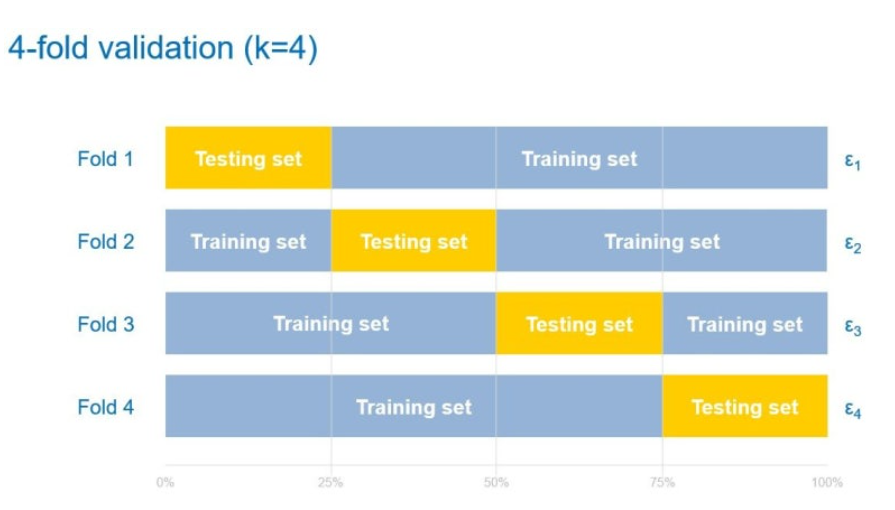

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/anandshaw2001/airlines-booking-csv/customer_booking.csv


In [3]:
df=pd.read_csv("/kaggle/input/datasets/anandshaw2001/airlines-booking-csv/customer_booking.csv",encoding="latin-1")

In [4]:
df.head(3)

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0


In [5]:
df=pd.get_dummies(df,columns=["sales_channel","trip_type","flight_day","route","booking_origin"],drop_first=True)

In [6]:
y=df["wants_extra_baggage"]
x=df.drop("wants_extra_baggage",axis=1)

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [8]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Columns: 919 entries, num_passengers to booking_origin_Vietnam
dtypes: bool(910), float64(1), int64(8)
memory usage: 46.8 MB


In [10]:
rf=RandomForestClassifier()
model=rf.fit(x_train,y_train)
rf.score(x_test,y_test)

0.73

In [11]:
from sklearn.model_selection import cross_val_score

In [12]:
crossval=cross_val_score(model,x,y,cv=4)
#Cross val train test gibi bir sağlama metodudur.

In [13]:
crossval

array([0.6716 , 0.42824, 0.3536 , 0.5404 ])

In [14]:
crossval.mean()

np.float64(0.49846)